In [2]:
import zipfile
import os

zip_path = "/content/UCI_Credit_Card.csv.zip"
extract_path = "/mnt/data/credit_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['UCI_Credit_Card.csv']

In [3]:
import pandas as pd

df = pd.read_csv("/mnt/data/credit_data/UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
# Drop ID column
df = df.drop("ID", axis=1)

# Target variable
y = df["default.payment.next.month"]

# Features
X = df.drop("default.payment.next.month", axis=1)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [7]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:,1]

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_models = {}

params = [(50,5),(100,10),(200,15)]

for n, depth in params:

    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=depth,
        random_state=42
    )

    rf.fit(X_train, y_train)

    rf_models[(n,depth)] = (
        rf.predict(X_test),
        rf.predict_proba(X_test)[:,1]
    )

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

In [10]:
results = []

results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    roc_auc_score(y_test, y_prob_dt)
])

results.append([
    "AdaBoost",
    accuracy_score(y_test, y_pred_ada),
    precision_score(y_test, y_pred_ada),
    recall_score(y_test, y_pred_ada),
    roc_auc_score(y_test, y_prob_ada)
])

In [11]:
for (n,depth),(pred,prob) in rf_models.items():

    results.append([
        f"RandomForest n={n}, depth={depth}",
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ])

In [12]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","ROC-AUC"]
)

results_df

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Decision Tree,0.725500,0.381054,0.407464,0.611086
1,AdaBoost,0.816667,0.677796,0.309216,0.770105
2,"RandomForest n=50, depth=5",0.816667,0.690519,0.293983,0.770942
3,"RandomForest n=100, depth=10",0.819333,0.663805,0.353389,0.777112
4,"RandomForest n=200, depth=15",0.819500,0.659280,0.362529,0.775483


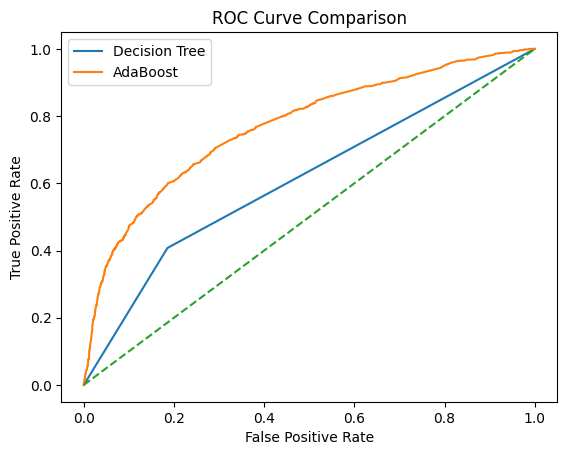

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure()

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr, tpr, label="Decision Tree")

# AdaBoost
fpr, tpr, _ = roc_curve(y_test, y_prob_ada)
plt.plot(fpr, tpr, label="AdaBoost")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

Decision Tree, AdaBoost, and Random Forest models were trained on the
credit card default dataset.

Random Forest models were tested with different n_estimators and max_depth values.

Models were compared using Accuracy, Precision, Recall, and ROC-AUC.

Random Forest generally performs better because it combines multiple
decision trees and reduces overfitting.

The model with highest ROC-AUC and Accuracy is considered the best model.